# 04 — Repeated embedding, film visibility, and temporal analyses

**Purpose.** Estimate the time-respecting repeated-embedding gradient, the continuous
time-respecting film-visibility association, and the broad event-time model; display the
strict exact-pre-attention matched temporal comparison constructed in notebook 03.

**Inputs.** `outputs/data/spotify_song_snapshot_panel.csv`,
`outputs/data/snapshot_time_respecting_exposures.csv`, `outputs/data/lastfm_song_panel.csv`
(notebook 01), and the strict temporal result objects (notebook 03).

**Outputs (result objects).** `results/repeated_embedding.csv`, `results/repeated_embedding_by_snapshot.csv`,
`results/visibility.csv`, `results/visibility_terciles.csv`,
`results/visibility_selection.csv`, `results/event_time.csv`, `results/event_time_support.csv`,
`results/embedding_visibility_cluster_rows.csv`.

**Unit of analysis.** Spotify song-snapshot observations (song records for Last.fm); pooled
models cluster inference by Billboard song-artist record because songs repeat across snapshots.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw_checksums.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

from cdr import paths, build, util
from cdr.util import SNAPSHOTS, SNAPSHOT_LABEL, check, show_and_save_table, show_and_save_figure

paths.ensure_output_dirs()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
RESULTS = paths.RESULTS

In [2]:
from cdr import temporal as tmp

panel_full = pd.read_csv(paths.OUT_DATA / "spotify_song_snapshot_panel.csv", low_memory=False)
exposures = pd.read_csv(paths.OUT_DATA / "snapshot_time_respecting_exposures.csv")
panel = build.merge_time_respecting(panel_full[panel_full["age"] >= 0], exposures)
lastfm = pd.read_csv(paths.OUT_DATA / "lastfm_song_panel.csv", low_memory=False)
print(f"Time-respecting panel: {len(panel):,} song-snapshots (nonnegative age)")

def fit_hc1_and_cluster(formula, data, terms, model_label, exposure_definition, interpretation, needed):
    """Fit one OLS specification with HC1 and cluster-by-song covariances and
    return one row per term of interest (same point estimates, two SEs)."""
    d = data.dropna(subset=needed).copy()
    hc1 = smf.ols(formula, data=d).fit(cov_type="HC1")
    cl = smf.ols(formula, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["song_artist_id"]})
    rows = []
    for term, term_label in terms:
        rows.append({
            "model": model_label, "term": term_label, "formula": formula,
            "exposure_definition": exposure_definition,
            "estimate": float(hc1.params[term]),
            "hc1_se": float(hc1.bse[term]),
            "hc1_ci_low": float(hc1.params[term] - 1.96 * hc1.bse[term]),
            "hc1_ci_high": float(hc1.params[term] + 1.96 * hc1.bse[term]),
            "cluster_se": float(cl.bse[term]),
            "cluster_ci_low": float(cl.params[term] - 1.96 * cl.bse[term]),
            "cluster_ci_high": float(cl.params[term] + 1.96 * cl.bse[term]),
            "cluster_p": float(cl.pvalues[term]),
            "n_observations": int(hc1.nobs),
            "n_clusters": int(d["song_artist_id"].nunique()),
            "interpretation": interpretation,
        })
    return rows

Time-respecting panel: 83,780 song-snapshots (nonnegative age)


## Repeated film embedding (time-respecting primary specification)

The primary Spotify specification counts only film appearances **released by each snapshot year**
(categories 0 / 1 / 2–3 / 4+ eligible films) and clusters inference by song across the
repeated song-snapshot observations:

`attention ~ C(movie_count_by_snapshot_cat, ref='0') + age + age^2 + weeks + peak_pos + C(snapshot)`

The lifetime-count variant (which can attach later films to earlier snapshots) is retained
only as a comparison to show the gradient is not an artifact of future film information.
Last.fm uses lifetime counts because only the single July 2017 snapshot exists.

In [3]:
TR_TERMS = [(f"C(movie_count_by_snapshot_cat, Treatment(reference='0'))[T.{c}]", f"{c} realized films vs none") for c in ["1", "2-3", "4+"]]
LT_TERMS = [(f"C(movie_count_cat, Treatment(reference='0'))[T.{c}]", f"{c} lifetime films vs none") for c in ["1", "2-3", "4+"]]

tr_rows = fit_hc1_and_cluster(
    "attention ~ C(movie_count_by_snapshot_cat, Treatment(reference='0')) + age + I(age**2) + weeks + peak_pos + C(snapshot)",
    panel, TR_TERMS, "Repeated embedding (time-respecting, primary)",
    "distinct films realized by each snapshot", "repeated-embedding attention gradient",
    ["attention", "movie_count_by_snapshot_cat", "age", "weeks", "peak_pos", "snapshot", "song_artist_id"])
lt_rows = fit_hc1_and_cluster(
    "attention ~ C(movie_count_cat, Treatment(reference='0')) + age + I(age**2) + weeks + peak_pos + C(snapshot)",
    panel, LT_TERMS, "Repeated embedding (lifetime comparison)",
    "lifetime distinct film count", "comparison specification (may attach later films to earlier snapshots)",
    ["attention", "movie_count_cat", "age", "weeks", "peak_pos", "snapshot", "song_artist_id"])

lastfm_rows = []
dlf = lastfm.dropna(subset=["attention", "movie_count_cat", "age", "weeks", "peak_pos"]).copy()
mlf = smf.ols("attention ~ C(movie_count_cat, Treatment(reference='0')) + age + I(age**2) + weeks + peak_pos", data=dlf).fit(cov_type="HC1")
for c in ["1", "2-3", "4+"]:
    term = f"C(movie_count_cat, Treatment(reference='0'))[T.{c}]"
    est, se, lo, hi, p = util.ci_from_model(mlf, term)
    lastfm_rows.append({"model": "Last.fm repeated embedding (lifetime)", "term": f"{c} lifetime films vs none",
                        "formula": "log1p listeners ~ C(movie_count_cat) + age + I(age**2) + weeks + peak_pos",
                        "exposure_definition": "lifetime distinct film count", "estimate": est, "hc1_se": se,
                        "hc1_ci_low": lo, "hc1_ci_high": hi, "n_observations": int(mlf.nobs),
                        "interpretation": "cumulative listener-reach gradient (single snapshot)"})

repeated = pd.DataFrame(tr_rows + lt_rows + lastfm_rows)
show_and_save_table(repeated.round(4), RESULTS / "repeated_embedding.csv")

tr = {r["term"]: r for r in tr_rows}
check(abs(tr["1 realized films vs none"]["estimate"] - 9.25) < 0.02, "1 realized film premium = 9.25 [8.73, 9.76]")
check(abs(tr["2-3 realized films vs none"]["estimate"] - 16.72) < 0.02, "2-3 realized films premium = 16.72 [16.05, 17.39]")
check(abs(tr["4+ realized films vs none"]["estimate"] - 24.19) < 0.02, "4+ realized films premium = 24.19 [23.35, 25.02]")
lf = {r["term"]: r for r in lastfm_rows}
check(abs(lf["1 lifetime films vs none"]["estimate"] - 1.34) < 0.01 and abs(lf["2-3 lifetime films vs none"]["estimate"] - 2.06) < 0.01 and abs(lf["4+ lifetime films vs none"]["estimate"] - 2.78) < 0.01, "Last.fm log-listener gradient = 1.34 / 2.06 / 2.78")
est_seq = [tr[t]["estimate"] for t in ["1 realized films vs none", "2-3 realized films vs none", "4+ realized films vs none"]]
check(est_seq == sorted(est_seq), "time-respecting embedding gradient is monotonic")

,model,term,formula,exposure_definition,estimate,hc1_se,hc1_ci_low,hc1_ci_high,cluster_se,cluster_ci_low,cluster_ci_high,cluster_p,n_observations,n_clusters,interpretation
0,"Repeated embedding (time-respecting, primary)",1 realized films vs none,"attention ~ C(movie_count_by_snapshot_cat, Tre...",distinct films realized by each snapshot,9.2452,0.1525,8.9462,9.5441,0.2637,8.7283,9.7620,0.0,83780,28281.0,repeated-embedding attention gradient
1,"Repeated embedding (time-respecting, primary)",2-3 realized films vs none,"attention ~ C(movie_count_by_snapshot_cat, Tre...",distinct films realized by each snapshot,16.7214,0.2032,16.3232,17.1196,0.3411,16.0529,17.3899,0.0,83780,28281.0,repeated-embedding attention gradient
2,"Repeated embedding (time-respecting, primary)",4+ realized films vs none,"attention ~ C(movie_count_by_snapshot_cat, Tre...",distinct films realized by each snapshot,24.1859,0.2489,23.6981,24.6737,0.4243,23.3542,25.0176,0.0,83780,28281.0,repeated-embedding attention gradient
3,Repeated embedding (lifetime comparison),1 lifetime films vs none,"attention ~ C(movie_count_cat, Treatment(refer...",lifetime distinct film count,9.2768,0.1512,8.9804,9.5733,0.2677,8.7521,9.8016,0.0,83780,28281.0,comparison specification (may attach later fil...
4,Repeated embedding (lifetime comparison),2-3 lifetime films vs none,"attention ~ C(movie_count_cat, Treatment(refer...",lifetime distinct film count,16.4287,0.1984,16.0398,16.8177,0.3483,15.7460,17.1115,0.0,83780,28281.0,comparison specification (may attach later fil...
5,Repeated embedding (lifetime comparison),4+ lifetime films vs none,"attention ~ C(movie_count_cat, Treatment(refer...",lifetime distinct film count,24.0822,0.2410,23.6099,24.5545,0.4204,23.2582,24.9062,0.0,83780,28281.0,comparison specification (may attach later fil...
6,Last.fm repeated embedding (lifetime),1 lifetime films vs none,log1p listeners ~ C(movie_count_cat) + age + I...,lifetime distinct film count,1.3367,0.0384,1.2615,1.4119,NaN,NaN,NaN,NaN,17988,NaN,cumulative listener-reach gradient (single sna...
7,Last.fm repeated embedding (lifetime),2-3 lifetime films vs none,log1p listeners ~ C(movie_count_cat) + age + I...,lifetime distinct film count,2.0596,0.0469,1.9677,2.1515,NaN,NaN,NaN,NaN,17988,NaN,cumulative listener-reach gradient (single sna...
8,Last.fm repeated embedding (lifetime),4+ lifetime films vs none,log1p listeners ~ C(movie_count_cat) + age + I...,lifetime distinct film count,2.7797,0.0535,2.6749,2.8846,NaN,NaN,NaN,NaN,17988,NaN,cumulative listener-reach gradient (single sna...


PASS: 1 realized film premium = 9.25 [8.73, 9.76]
PASS: 2-3 realized films premium = 16.72 [16.05, 17.39]
PASS: 4+ realized films premium = 24.19 [23.35, 25.02]
PASS: Last.fm log-listener gradient = 1.34 / 2.06 / 2.78
PASS: time-respecting embedding gradient is monotonic


### Snapshot-specific time-respecting embedding geometry

For the main embedding figure, the same time-respecting specification is estimated within
each snapshot (each song appears once per snapshot, so HC1 intervals apply):

`attention ~ C(movie_count_by_snapshot_cat, ref='0') + age + age^2 + weeks + peak_pos`

The pooled cluster-by-song estimates above remain the primary manuscript estimates; the
snapshot-specific series are visual evidence that the graded pattern is temporally consistent.
No future film appearance affects an earlier snapshot.

In [4]:
support_by_snap = (
    panel.groupby(["snapshot", "movie_count_by_snapshot_cat"])["song_artist_id"].size()
    .rename("n_song_snapshots").reset_index()
)
display(support_by_snap.pivot(index="snapshot", columns="movie_count_by_snapshot_cat", values="n_song_snapshots"))

by_snap_rows = []
for snap, g in panel.groupby("snapshot"):
    d = g.dropna(subset=["attention", "movie_count_by_snapshot_cat", "age", "weeks", "peak_pos"]).copy()
    mod = smf.ols("attention ~ C(movie_count_by_snapshot_cat, Treatment(reference='0')) + age + I(age**2) + weeks + peak_pos", data=d).fit(cov_type="HC1")
    for c in ["1", "2-3", "4+"]:
        term = f"C(movie_count_by_snapshot_cat, Treatment(reference='0'))[T.{c}]"
        if term not in mod.params.index:
            continue  # honest omission when a category has no realized support in the snapshot
        est, se, lo, hi, p = util.ci_from_model(mod, term)
        n_cat = int(d["movie_count_by_snapshot_cat"].eq(c).sum())
        by_snap_rows.append({"snapshot": snap, "category": f"{c} realized films", "estimate": est,
                             "std_error": se, "conf_low": lo, "conf_high": hi, "p_value": p,
                             "n_category": n_cat, "n_snapshot": int(mod.nobs)})
embedding_by_snapshot = pd.DataFrame(by_snap_rows)
show_and_save_table(embedding_by_snapshot.round(4), RESULTS / "repeated_embedding_by_snapshot.csv")
check(embedding_by_snapshot["n_category"].min() >= 30, "every plotted snapshot/category cell has adequate realized-film support")
for snap, g in embedding_by_snapshot.groupby("snapshot"):
    est_seq = g.set_index("category").loc[["1 realized films", "2-3 realized films", "4+ realized films"], "estimate"].tolist()
    print(f"{snap}: gradient {est_seq[0]:.2f} -> {est_seq[1]:.2f} -> {est_seq[2]:.2f}")

movie_count_by_snapshot_cat,0,1,2-3,4+
snapshot,,,,
2016-10,13796,1937,954,659
2017-07,14300,2166,1031,691
2022-08,17676,2395,1182,849
2025,21462,2533,1256,893


,snapshot,category,estimate,std_error,conf_low,conf_high,p_value,n_category,n_snapshot
0,2016-10,1 realized films,7.6481,0.3047,7.0509,8.2454,0.0,1937,17346
1,2016-10,2-3 realized films,15.0988,0.4044,14.3062,15.8914,0.0,954,17346
2,2016-10,4+ realized films,22.6357,0.4940,21.6673,23.6040,0.0,659,17346
3,2017-07,1 realized films,8.6452,0.3060,8.0455,9.2449,0.0,2166,18188
4,2017-07,2-3 realized films,16.6278,0.4011,15.8416,17.4139,0.0,1031,18188
5,2017-07,4+ realized films,24.0227,0.5214,23.0007,25.0446,0.0,691,18188
6,2022-08,1 realized films,10.0876,0.3003,9.4991,10.6762,0.0,2395,22102
7,2022-08,2-3 realized films,16.9046,0.4141,16.0930,17.7162,0.0,1182,22102
8,2022-08,4+ realized films,23.8640,0.5127,22.8591,24.8689,0.0,849,22102
9,2025,1 realized films,10.3062,0.2991,9.7201,10.8924,0.0,2533,26144


PASS: every plotted snapshot/category cell has adequate realized-film support
2016-10: gradient 7.65 -> 15.10 -> 22.64
2017-07: gradient 8.65 -> 16.63 -> 24.02
2022-08: gradient 10.09 -> 16.90 -> 23.86
2025: gradient 10.31 -> 17.99 -> 25.75


## Continuous time-respecting film visibility

Among song-snapshots linked to films released by the snapshot year with recorded
worldwide box office (support validated in notebook 01: 15,245 song-snapshots,
4,294 normalized song-artist identities):

`attention ~ log1p(max recorded worldwide box office among films released by snapshot year) + age + age^2 + weeks + peak_pos + movie_count_by_snapshot + C(snapshot)`

with cluster-by-song inference. Box office measures film-level visibility, not the prominence
of a song within a scene or soundtrack. The support diagnostics split the model's own
eligible universe — song-snapshots with at least one film released by the snapshot year —
by recorded worldwide box-office availability. The row with observed box office is exactly
the continuous model's estimation sample (the complete-case condition drops no rows).
Recorded box-office totals may include receipts after the snapshot date.


In [5]:
vis = panel[
    panel["film_linked_by_snapshot"].eq(1)
    & panel["max_worldwide_boxoffice_by_snapshot"].notna()
    & (panel["max_worldwide_boxoffice_by_snapshot"] > 0)
].copy()
vis["log1p_max_worldwide_by_snapshot"] = np.log1p(vis["max_worldwide_boxoffice_by_snapshot"])
vis_rows = fit_hc1_and_cluster(
    "attention ~ log1p_max_worldwide_by_snapshot + age + I(age**2) + weeks + peak_pos + movie_count_by_snapshot + C(snapshot)",
    vis, [("log1p_max_worldwide_by_snapshot", "log1p max worldwide box office realized by snapshot")],
    "Film visibility (continuous, time-respecting, primary)",
    "maximum worldwide box office realized by each snapshot",
    "film-level visibility gradient among film-linked observations",
    ["attention", "log1p_max_worldwide_by_snapshot", "age", "weeks", "peak_pos", "movie_count_by_snapshot", "snapshot", "song_artist_id"])
visibility = pd.DataFrame(vis_rows)
show_and_save_table(visibility.round(4), RESULTS / "visibility.csv")
v = vis_rows[0]
check(abs(v["estimate"] - 1.15) < 0.01, "visibility gradient = 1.15 points per log1p box-office unit")
check(abs(v["cluster_ci_low"] - 0.95) < 0.02 and abs(v["cluster_ci_high"] - 1.35) < 0.02, "visibility cluster 95% CI = [0.95, 1.35]")
check(v["n_observations"] == 15245 and v["n_clusters"] == 4294, "visibility support = 15,245 song-snapshots, 4,294 unique songs")

# Support diagnostics on the model's own eligible universe: time-respecting
# film-linked song-snapshots (>= 1 film realized by the snapshot), split by
# whether realized worldwide box office is observed by the snapshot. The
# realized-box-office row must equal the continuous-model support exactly.
selection = (
    panel[panel["film_linked_by_snapshot"].eq(1)]
    .assign(has_realized_boxoffice=lambda d: d["max_worldwide_boxoffice_by_snapshot"].notna() & (d["max_worldwide_boxoffice_by_snapshot"] > 0))
    .groupby("has_realized_boxoffice")
    .agg(n_song_snapshots=("song_artist_id", "size"), n_unique_songs=("song_artist_id", "nunique"),
         mean_age=("age", "mean"), mean_weeks=("weeks", "mean"), mean_peak_pos=("peak_pos", "mean"),
         mean_realized_films=("movie_count_by_snapshot", "mean"), mean_spotify_popularity=("attention", "mean"))
    .reset_index()
)
show_and_save_table(selection.round(3), RESULTS / "visibility_selection.csv")
sel_realized = selection.set_index("has_realized_boxoffice").loc[True]
check(int(sel_realized["n_song_snapshots"]) == int(v["n_observations"])
      and int(sel_realized["n_unique_songs"]) == int(v["n_clusters"]),
      "selection-table realized-box-office row equals the continuous-model support exactly")
check(not (panel.loc[panel["film_linked_by_snapshot"].eq(1), "max_worldwide_boxoffice_by_snapshot"] == 0).any(),
      "unrealized box office in the eligible universe is missing data, never a zero value")

,model,term,formula,exposure_definition,estimate,hc1_se,hc1_ci_low,hc1_ci_high,cluster_se,cluster_ci_low,cluster_ci_high,cluster_p,n_observations,n_clusters,interpretation
0,"Film visibility (continuous, time-respecting, ...",log1p max worldwide box office realized by sna...,attention ~ log1p_max_worldwide_by_snapshot + ...,maximum worldwide box office realized by each ...,1.1465,0.0581,1.0326,1.2604,0.1016,0.9474,1.3457,0.0,15245,4294,film-level visibility gradient among film-link...


PASS: visibility gradient = 1.15 points per log1p box-office unit
PASS: visibility cluster 95% CI = [0.95, 1.35]
PASS: visibility support = 15,245 song-snapshots, 4,294 unique songs


,has_realized_boxoffice,n_song_snapshots,n_unique_songs,mean_age,mean_weeks,mean_peak_pos,mean_realized_films,mean_spotify_popularity
0,False,1301,430,44.255,12.919,33.877,1.056,40.899
1,True,15245,4294,38.713,15.855,26.492,2.549,50.287


PASS: selection-table realized-box-office row equals the continuous-model support exactly
PASS: unrealized box office in the eligible universe is missing data, never a zero value


### Recorded-box-office terciles (visualization projection)

To make the gradient's shape visible, the same complete-case support is split into terciles of
maximum recorded worldwide box office among films released by the snapshot year
(an outcome-independent binning rule on the same support), and adjusted contrasts relative
to the low tercile are estimated with the same substantive control family and cluster-by-song
inference. The bins visualize shape; the continuous model above remains the primary
visibility estimate.


In [6]:
vis_t = vis.copy()
vis_t["visibility_tercile"] = pd.qcut(vis_t["max_worldwide_boxoffice_by_snapshot"], 3, labels=["low", "middle", "high"]).astype(str)
tercile_support = (
    vis_t.groupby("visibility_tercile")
    .agg(n_song_snapshots=("attention", "size"), n_unique_songs=("song_artist_id", "nunique"),
         min_box=("max_worldwide_boxoffice_by_snapshot", "min"), max_box=("max_worldwide_boxoffice_by_snapshot", "max"))
    .reindex(["low", "middle", "high"]).reset_index()
)
display(tercile_support)
d = vis_t.dropna(subset=["attention", "visibility_tercile", "age", "weeks", "peak_pos", "movie_count_by_snapshot"]).copy()
mod_hc1 = smf.ols("attention ~ C(visibility_tercile, Treatment(reference='low')) + age + I(age**2) + weeks + peak_pos + movie_count_by_snapshot + C(snapshot)", data=d).fit(cov_type="HC1")
mod_cl = smf.ols("attention ~ C(visibility_tercile, Treatment(reference='low')) + age + I(age**2) + weeks + peak_pos + movie_count_by_snapshot + C(snapshot)", data=d).fit(cov_type="cluster", cov_kwds={"groups": d["song_artist_id"]})
tercile_rows = [{"tercile": "low", "adjusted_contrast_vs_low": 0.0, "conf_low": np.nan, "conf_high": np.nan,
                 "n_song_snapshots": int(tercile_support.loc[0, "n_song_snapshots"]), "role": "reference"}]
for t in ["middle", "high"]:
    term = f"C(visibility_tercile, Treatment(reference='low'))[T.{t}]"
    est = float(mod_hc1.params[term])
    lo = float(mod_cl.params[term] - 1.96 * mod_cl.bse[term])
    hi = float(mod_cl.params[term] + 1.96 * mod_cl.bse[term])
    tercile_rows.append({"tercile": t, "adjusted_contrast_vs_low": est, "conf_low": lo, "conf_high": hi,
                         "n_song_snapshots": int(tercile_support.set_index("visibility_tercile").loc[t, "n_song_snapshots"]),
                         "role": "adjusted contrast, cluster-by-song 95% CI"})
visibility_terciles = pd.DataFrame(tercile_rows)
show_and_save_table(visibility_terciles.round(4), RESULTS / "visibility_terciles.csv")
check(int(len(d)) == 15245, "tercile projection uses the same 15,245-observation complete-case support as the continuous model")
mid, high = visibility_terciles.set_index("tercile").loc[["middle", "high"], "adjusted_contrast_vs_low"]
check(high > mid > 0, "adjusted realized-visibility gradient is monotonic across terciles")

,visibility_tercile,n_song_snapshots,n_unique_songs,min_box,max_box
0,low,5085,1497,52.0,2.821592e+07
1,middle,5080,1456,28460702.0,1.412207e+08
2,high,5080,1480,141522961.0,2.797501e+09


,tercile,adjusted_contrast_vs_low,conf_low,conf_high,n_song_snapshots,role
0,low,0.0000,NaN,NaN,5085,reference
1,middle,3.7315,2.8391,4.6240,5080,"adjusted contrast, cluster-by-song 95% CI"
2,high,6.3712,5.3865,7.3558,5080,"adjusted contrast, cluster-by-song 95% CI"


PASS: tercile projection uses the same 15,245-observation complete-case support as the continuous model
PASS: adjusted realized-visibility gradient is monotonic across terciles


## Broad song event-time model

Event time is measured relative to the first observed film appearance. Bins: at least two
years before (`<= -2`), the immediate pre-event year and never-film songs (**omitted reference
category** `-1`), the event-year snapshot (`0`), one-to-five years post (`1 to 5`), and more
than five years post (`>5`):

`attention ~ C(event_bin, ref='-1') + age + age^2 + weeks + peak_pos + C(snapshot)`

on all 83,785 song-snapshot observations, HC1 intervals (cluster-by-song stored alongside).
A positive pre-event bin documents an attention difference that predates observed film placement.

In [7]:
d_ev = panel_full.copy()
d_ev["event_bin"] = tmp.event_bins(d_ev["rel_time"])
d_ev.loc[d_ev["film_linked"].eq(0), "event_bin"] = "-1"
d_ev = d_ev[d_ev["event_bin"].isin(["<= -2", "-1", "0", "1 to 5", ">5"])]
EV_TERMS = [(f"C(event_bin, Treatment(reference='-1'))[T.{b}]", lab) for b, lab in
            [("<= -2", "pre (<= -2 years)"), ("0", "event year"), ("1 to 5", "1-5 years post"), (">5", ">5 years post")]]
ev_rows = fit_hc1_and_cluster(
    "attention ~ C(event_bin, Treatment(reference='-1')) + age + I(age**2) + weeks + peak_pos + C(snapshot)",
    d_ev, EV_TERMS, "Song event-time model (broad)",
    "years relative to first observed film appearance; never-film and immediate pre-year form the omitted reference",
    "temporal consistency and selection pattern",
    ["attention", "event_bin", "age", "weeks", "peak_pos", "snapshot", "song_artist_id"])
event_time = pd.DataFrame(ev_rows)
show_and_save_table(event_time.round(4), RESULTS / "event_time.csv")

support = (
    d_ev[d_ev["film_linked"].eq(1)].groupby("event_bin")
    .agg(n_song_snapshots=("attention", "size"), n_unique_songs=("song_artist_id", "nunique"))
    .reset_index()
)
show_and_save_table(support, RESULTS / "event_time_support.csv")

ev = {r["term"]: r for r in ev_rows}
check(event_time["n_observations"].iloc[0] == 83785, "event-time model uses 83,785 song-snapshot observations")
check(abs(ev["pre (<= -2 years)"]["estimate"] - 9.4986) < 0.005, "pre-event bin = 9.50 (selection into film placement)")
check(abs(ev["event year"]["estimate"] - 11.2304) < 0.005, "event-year contrast = 11.23")
check(abs(ev["1-5 years post"]["estimate"] - 10.1609) < 0.005, "1-5 year post bin = 10.16")
check(abs(ev[">5 years post"]["estimate"] - 14.1802) < 0.005, ">5 year post bin = 14.18")

cluster_rows = pd.concat([pd.DataFrame(tr_rows), visibility, event_time], ignore_index=True)
cluster_rows.to_csv(RESULTS / "embedding_visibility_cluster_rows.csv", index=False)

,model,term,formula,exposure_definition,estimate,hc1_se,hc1_ci_low,hc1_ci_high,cluster_se,cluster_ci_low,cluster_ci_high,cluster_p,n_observations,n_clusters,interpretation
0,Song event-time model (broad),pre (<= -2 years),"attention ~ C(event_bin, Treatment(reference='...",years relative to first observed film appearan...,9.4986,0.6711,8.1833,10.8139,0.8650,7.8032,11.1939,0.0,83785,28281,temporal consistency and selection pattern
1,Song event-time model (broad),event year,"attention ~ C(event_bin, Treatment(reference='...",years relative to first observed film appearan...,11.2304,0.9080,9.4507,13.0100,0.9110,9.4448,13.0160,0.0,83785,28281,temporal consistency and selection pattern
2,Song event-time model (broad),1-5 years post,"attention ~ C(event_bin, Treatment(reference='...",years relative to first observed film appearan...,10.1609,0.3568,9.4615,10.8603,0.4359,9.3065,11.0153,0.0,83785,28281,temporal consistency and selection pattern
3,Song event-time model (broad),>5 years post,"attention ~ C(event_bin, Treatment(reference='...",years relative to first observed film appearan...,14.1802,0.1363,13.9130,14.4474,0.2390,13.7118,14.6485,0.0,83785,28281,temporal consistency and selection pattern


,event_bin,n_song_snapshots,n_unique_songs
0,-1,272,207
1,0,184,184
2,1 to 5,1046,747
3,<= -2,343,213
4,>5,15102,4503


PASS: event-time model uses 83,785 song-snapshot observations
PASS: pre-event bin = 9.50 (selection into film placement)
PASS: event-year contrast = 11.23
PASS: 1-5 year post bin = 10.16
PASS: >5 year post bin = 14.18


## Strict exact-pre-attention matched temporal comparison (display)

The design and the excess-attention re-expression are constructed once in notebook 03
(one result object per analytical family); here the raw-scale results, cohort support, and
covariate balance are displayed for the temporal-evidence family.

In [8]:
strict_pooled = pd.read_csv(RESULTS / "strict_temporal_pooled.csv")
strict_effects = pd.read_csv(RESULTS / "strict_temporal_effects.csv")
strict_balance = pd.read_csv(RESULTS / "strict_temporal_balance.csv")
print("Pooled contrasts at the exact-baseline (caliper 0) specification:")
display(strict_pooled[strict_pooled["caliper"].eq(0)].round(4))
print("Cohort-level contrasts (2017 cohort: 60 pairs; 2022 cohort: 33 pairs):")
display(strict_effects[strict_effects["caliper"].eq(0)].round(4))
print("Covariate balance (exact baseline attention; SMDs on chart history):")
display(strict_balance[strict_balance["caliper"].eq(0)].round(3))
check(strict_balance[strict_balance["caliper"].eq(0)]["baseline_smd"].abs().max() == 0, "baseline Spotify attention is exactly balanced (caliper 0)")

Pooled contrasts at the exact-baseline (caliper 0) specification:


,caliper,contrast,estimate,std_error,n_pairs,p_value,randomization_p
0,0,event,2.4301,0.9359,93,0.0110,0.0102
1,0,post,2.9355,0.9186,93,0.0019,0.0012


Cohort-level contrasts (2017 cohort: 60 pairs; 2022 cohort: 33 pairs):


,caliper,cohort,contrast,estimate,std_error,n_pairs,p_value,randomization_p
0,0,2017,event,2.3000,0.8898,60,0.0122,0.0110
1,0,2017,post_1,3.1167,1.1525,60,0.0089,0.0096
2,0,2017,post_2,3.0500,1.4518,60,0.0399,0.0436
15,0,2022,event,2.6667,2.1073,33,0.2148,0.2404
16,0,2022,post_1,2.6061,1.5423,33,0.1008,0.1052
17,0,2022,pre_placebo,0.2727,1.0190,33,0.7907,0.8180


Covariate balance (exact baseline attention; SMDs on chart history):


,cohort,caliper,matched_pairs,mean_abs_baseline_diff,max_abs_baseline_diff,baseline_smd,chart_year_smd,weeks_smd,peak_smd
0,2017,0,60,0.0,0.0,0.0,-0.055,0.012,-0.036
5,2022,0,33,0.0,0.0,0.0,-0.099,0.048,-0.034


PASS: baseline Spotify attention is exactly balanced (caliper 0)


## Paper artifacts for this section

Figure 3, the embedding/visibility/temporal SI tables, and the cross-platform embedding SI figure are generated here, from the result objects this notebook produces.

In [3]:
# Paper-artifact helpers: shared figure style, LaTeX writers, result-object reader.
from matplotlib.gridspec import GridSpec

from cdr import tex
from cdr.tex import fmt_num, fmt_int, fmt_p, fmt_ci
from cdr.util import (ACCENT, BLUE, CHARCOAL, COV_LABEL, DARK_BLUE, GRAY, GREEN, GRID,
                      LIGHT_BLUE, LIGHT_GRAY, SNAP_SHORT, errorbarh, errorbarv,
                      panel_label, set_plot_style)

set_plot_style()
R = lambda name: pd.read_csv(RESULTS / name, low_memory=False)

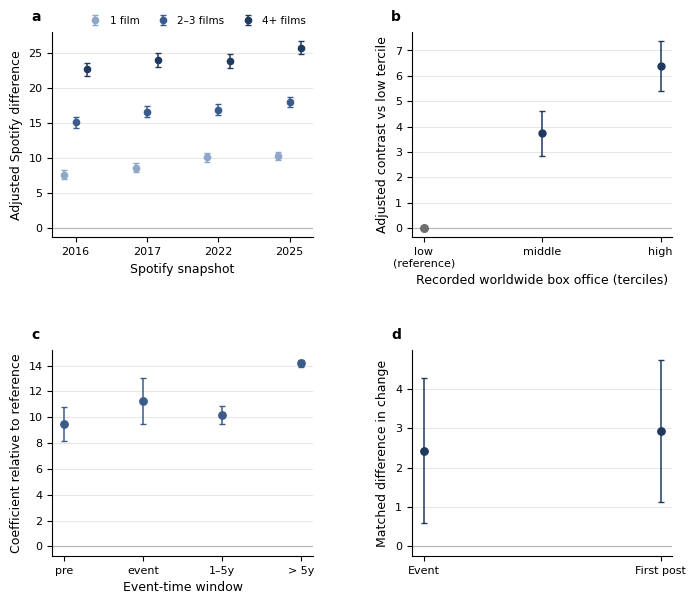

In [4]:
repeated = R("repeated_embedding.csv")
visibility = R("visibility.csv")
event_time = R("event_time.csv")
strict_pooled = R("strict_temporal_pooled.csv")

def plot_fig3_a(ax):
    d = R("repeated_embedding_by_snapshot.csv")
    snaps = [s[0] for s in SNAPSHOTS]
    x = np.arange(len(snaps))
    series = [("1 realized films", "1 film", LIGHT_BLUE, -0.16), ("2-3 realized films", "2–3 films", BLUE, 0.0), ("4+ realized films", "4+ films", DARK_BLUE, 0.16)]
    for cat, label, color, off in series:
        g = d[d["category"].eq(cat)].set_index("snapshot").reindex(snaps)
        ax.errorbar(x + off, g["estimate"], yerr=[g["estimate"] - g["conf_low"], g["conf_high"] - g["estimate"]],
                    fmt="o", color=color, ecolor=color, elinewidth=1.1, capsize=2.5, markersize=4.5, label=label)
    ax.axhline(0, color=LIGHT_GRAY, lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([SNAP_SHORT[s] for s in snaps])
    ax.set_ylabel("Adjusted Spotify difference")
    ax.set_xlabel("Spotify snapshot")
    ax.legend(frameon=False, fontsize=7.5, loc="lower center", bbox_to_anchor=(0.55, 1.01),
              ncol=3, columnspacing=1.3, handletextpad=0.35, borderaxespad=0.0)
    ax.grid(axis="y", color=GRID, lw=0.7)

def plot_fig3_b(ax):
    t = R("visibility_terciles.csv").set_index("tercile")
    v = visibility.iloc[0]
    x = np.arange(3)
    labels = ["low", "middle", "high"]
    est = t.loc[labels, "adjusted_contrast_vs_low"].to_numpy()
    lo = t.loc[labels, "conf_low"].to_numpy()
    hi = t.loc[labels, "conf_high"].to_numpy()
    ax.scatter([0], [0], s=30, color=GRAY, zorder=3)
    ax.errorbar(x[1:], est[1:], yerr=[est[1:] - lo[1:], hi[1:] - est[1:]], fmt="o", color=DARK_BLUE, ecolor=DARK_BLUE, elinewidth=1.1, capsize=2.5, markersize=5)
    ax.axhline(0, color=LIGHT_GRAY, lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(["low\n(reference)", "middle", "high"])
    ax.set_ylabel("Adjusted contrast vs low tercile")
    ax.set_xlabel("Recorded worldwide box office (terciles)")
    ax.grid(axis="y", color=GRID, lw=0.7)

def plot_fig3_c(ax):
    d = event_time.set_index("term")
    order = ["pre (<= -2 years)", "event year", "1-5 years post", ">5 years post"]
    labels = ["pre", "event", "1\u20135y", "> 5y"]
    x = np.arange(4)
    errorbarv(ax, x, d.loc[order, "estimate"], d.loc[order, "hc1_ci_low"], d.loc[order, "hc1_ci_high"], color=BLUE, size=28)
    ax.axhline(0, color=LIGHT_GRAY, lw=0.9)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("Coefficient relative to reference"); ax.set_xlabel("Event-time window")
    ax.grid(axis="y", color=GRID, lw=0.7)

def plot_fig3_d(ax):
    d = strict_pooled[strict_pooled["caliper"].eq(0)].set_index("contrast")
    x = np.arange(2)
    est = d.loc[["event", "post"], "estimate"].to_numpy()
    se = d.loc[["event", "post"], "std_error"].to_numpy()
    errorbarv(ax, x, est, est - 1.96 * se, est + 1.96 * se, color=DARK_BLUE, size=28)
    ax.axhline(0, color=LIGHT_GRAY, lw=0.9)
    ax.set_xticks(x); ax.set_xticklabels(["Event", "First post"])
    ax.set_ylabel("Matched difference in change"); ax.grid(axis="y", color=GRID, lw=0.7)

fig = plt.figure(figsize=(8.0, 6.8))
gs = GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.38)
axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]
plot_fig3_a(axes[0]); plot_fig3_b(axes[1]); plot_fig3_c(axes[2]); plot_fig3_d(axes[3])
for label, ax in zip(["a", "b", "c", "d"], axes):
    panel_label(ax, label)
show_and_save_figure(fig, paths.OUT_FIG_MAIN / "figure3_embedding_visibility_temporal.pdf")

In [11]:
# S: repeated embedding -- C17
rows = []
for _, r in repeated.iterrows():
    ci_txt = fmt_ci(r["cluster_ci_low"], r["cluster_ci_high"]) if pd.notna(r.get("cluster_ci_low")) else fmt_ci(r["hc1_ci_low"], r["hc1_ci_high"])
    se_txt = fmt_num(r["cluster_se"], 3) if pd.notna(r.get("cluster_se")) else fmt_num(r["hc1_se"], 3)
    rows.append([r["model"], r["term"], fmt_num(r["estimate"]), se_txt, ci_txt, fmt_int(r["n_observations"]), fmt_int(r.get("n_clusters"))])
tex.write_table(paths.OUT_TABLES_SI / "table_si_repeated_embedding.tex",
    "Repeated film embedding: time-respecting primary specification, lifetime comparison, and Last.fm.", "tab:si-repeated-embedding",
    ["Model", "Term", "Estimate", "SE", "95\\% CI", "N obs.", "N songs"],
    rows,
    note="Spotify models adjust for age, squared age, Billboard weeks, peak position, and snapshot fixed effects; the primary specification counts only film appearances realized by each snapshot and reports cluster-by-song intervals. The lifetime comparison shows the gradient is not an artifact of attaching later films to earlier snapshots. Last.fm uses log1p cumulative listeners with lifetime counts (single snapshot) and HC1 intervals.",
    col_spec=r">{\raggedright\arraybackslash}p{0.25\linewidth}>{\raggedright\arraybackslash}p{0.17\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.05\linewidth}>{\centering\arraybackslash}p{0.10\linewidth}>{\centering\arraybackslash}p{0.06\linewidth}>{\centering\arraybackslash}p{0.06\linewidth}",
    size=r"\footnotesize", stretch=1.05, tabcolsep="3pt", escape_cells=False)

# S: visibility models -- C18
v = visibility.iloc[0]
visibility_term_label = 'log1p max recorded worldwide box office; films released by snapshot year'
rows = [[v["model"], visibility_term_label, fmt_num(v["estimate"]), fmt_num(v["cluster_se"], 3), fmt_ci(v["cluster_ci_low"], v["cluster_ci_high"]), fmt_int(v["n_observations"]), fmt_int(v["n_clusters"])]]
tex.write_table(paths.OUT_TABLES_SI / "table_si_visibility_models.tex",
    "Continuous time-respecting film-visibility model.", "tab:si-visibility-models",
    ["Model", "Term", "Estimate", r"\makecell[b]{Cluster\\ SE}", "95\\% CI", "N obs.", "N songs"],
    rows,
    note="Song-snapshots linked to films released by the snapshot year with recorded worldwide box office. Recorded totals may include receipts after the snapshot date. The model adjusts for age, squared age, Billboard weeks, peak position, realized film count, and snapshot fixed effects, with cluster-by-song intervals. Box office measures film-level visibility, not scene-level soundtrack prominence.",
    col_spec=r">{\raggedright\arraybackslash}p{0.22\linewidth}>{\raggedright\arraybackslash}p{0.20\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.07\linewidth}>{\centering\arraybackslash}p{0.095\linewidth}>{\centering\arraybackslash}p{0.06\linewidth}>{\centering\arraybackslash}p{0.06\linewidth}",
    size=r"\footnotesize", stretch=1.05, tabcolsep="3pt", escape_cells=False)

# S: visibility support and selection -- C18 missingness threat
sel = R("visibility_selection.csv")
vis_support_n, vis_support_songs = int(visibility.iloc[0]["n_observations"]), int(visibility.iloc[0]["n_clusters"])
sel_real = sel[sel["has_realized_boxoffice"]].iloc[0]
check(int(sel_real["n_song_snapshots"]) == vis_support_n and int(sel_real["n_unique_songs"]) == vis_support_songs,
      "selection-table observed-box-office row equals the continuous visibility-model support")
rows = []
for _, r in sel.iterrows():
    rows.append(["with recorded worldwide box office" if r["has_realized_boxoffice"] else "without recorded worldwide box office",
                 fmt_int(r["n_song_snapshots"]), fmt_int(r["n_unique_songs"]), fmt_num(r["mean_age"], 1), fmt_num(r["mean_weeks"], 1),
                 fmt_num(r["mean_peak_pos"], 1), fmt_num(r["mean_realized_films"]), fmt_num(r["mean_spotify_popularity"], 1)])
tex.write_table(paths.OUT_TABLES_SI / "table_si_visibility_selection.tex",
    "Support and selection diagnostics for the film-visibility model.", "tab:si-visibility-selection",
    ["Time-respecting film-linked observations", "N obs.", "N songs", r"\makecell[b]{Mean\\ age}", r"\makecell[b]{Mean\\ weeks}", r"\makecell[b]{Mean\\ peak}", r"\makecell[b]{Mean\\ realized\\ films}", r"\makecell[b]{Mean\\ popularity}"],
    rows,
    note=("The universe is every song-snapshot linked to at least one film released by the snapshot year. "
          "Rows split this universe by whether positive worldwide box office is recorded for at least one eligible film. "
          "Recorded totals may include receipts after the snapshot date. The row with observed box office is exactly the estimation sample of the "
          f"continuous visibility model and its tercile visualization ({vis_support_n:,} song-snapshots, {vis_support_songs:,} normalized song-artist identities); "
          "the model's complete-case condition drops no observations."),
    col_spec=r">{\raggedright\arraybackslash}p{0.21\linewidth}>{\centering\arraybackslash}p{0.06\linewidth}>{\centering\arraybackslash}p{0.055\linewidth}>{\centering\arraybackslash}p{0.05\linewidth}>{\centering\arraybackslash}p{0.055\linewidth}>{\centering\arraybackslash}p{0.05\linewidth}>{\centering\arraybackslash}p{0.085\linewidth}>{\centering\arraybackslash}p{0.10\linewidth}",
    size=r"\footnotesize", stretch=1.05, tabcolsep="3pt")

# S: temporal event-time -- C19
evs = R("event_time_support.csv").set_index("event_bin")
bin_of = {"pre (<= -2 years)": "<= -2", "event year": "0", "1-5 years post": "1 to 5", ">5 years post": ">5"}
rows = []
for _, r in event_time.iterrows():
    b = bin_of[r["term"]]
    rows.append([r["term"], fmt_num(r["estimate"]), fmt_num(r["hc1_se"], 3), fmt_ci(r["hc1_ci_low"], r["hc1_ci_high"]), fmt_ci(r["cluster_ci_low"], r["cluster_ci_high"]), fmt_int(evs.loc[b, "n_song_snapshots"]), fmt_int(evs.loc[b, "n_unique_songs"])])
tex.write_table(paths.OUT_TABLES_SI / "table_si_temporal_event_time.tex",
    "Broad song event-time model relative to the first observed film appearance.", "tab:si-temporal-event-time",
    ["Event bin", "Estimate", "HC1 SE", "HC1 95\\% CI", "Cluster 95\\% CI", "N film-linked obs.", "N songs"],
    rows,
    note="All 83{,}785 song-snapshot observations; never-film songs and the immediate pre-year form the omitted reference. Adjusts for age, squared age, Billboard weeks, peak position, and snapshot fixed effects. The positive $\\leq -2$ bin is direct evidence of selection into film placement. Support columns count film-linked observations in each bin.",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

# S: strict temporal -- C20
eff = R("strict_temporal_effects.csv")
eff0 = eff[eff["caliper"].eq(0)]
CONTRAST_LABEL = {"event": "event year", "post": "first post", "post_1": "first post", "post_2": "second post", "pre_placebo": "pre-period placebo"}
rows = []
p0 = strict_pooled[strict_pooled["caliper"].eq(0)]
for _, r in p0.iterrows():
    rows.append(["pooled", CONTRAST_LABEL.get(r["contrast"], r["contrast"]), fmt_int(r["n_pairs"]), fmt_num(r["estimate"]), fmt_num(r["std_error"], 3), fmt_p(r["p_value"]), fmt_p(r["randomization_p"])])
for _, r in eff0.iterrows():
    rows.append([f"{int(r['cohort'])} cohort", CONTRAST_LABEL.get(r["contrast"], r["contrast"]), fmt_int(r["n_pairs"]), fmt_num(r["estimate"]), fmt_num(r["std_error"], 3), fmt_p(r["p_value"]), fmt_p(r["randomization_p"])])
tex.write_table(paths.OUT_TABLES_SI / "table_si_strict_temporal.tex",
    "Strict exact-pre-attention matched temporal comparison (raw Spotify scale).", "tab:si-strict-temporal",
    ["Level", "Contrast", "Pairs", "Estimate", "SE", "$t$-test $p$", "Randomization $p$"],
    rows,
    note="Optimal 1:1 matching without replacement under a hard zero-point caliper on baseline Spotify attention with standardized chart-history distance as tie-breaker. The 2017 cohort (60 pairs) uses October 2016 as baseline; the 2022 cohort (33 pairs) uses July 2017; the 2022 pre-placebo contrast checks the 2016--2017 pre-period. Because exact prior-attention matching yields the same matched support across the evaluated nonnegative caliper settings (0, 1, 2, 3, 5 points), redundant caliper rows are omitted. Randomization $p$-values use 5{,}000 sign-flip draws.",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

**Repeated film embedding: time-respecting primary specification, lifetime comparison, and Last.fm.** (`tab:si-repeated-embedding`)

,Model,Term,Estimate,SE,95% CI,N obs.,N songs
0,"Repeated embedding (time-respecting, primary)",1 realized films vs none,9.25,0.264,"[8.73, 9.76]","83,780","28,281"
1,"Repeated embedding (time-respecting, primary)",2-3 realized films vs none,16.72,0.341,"[16.05, 17.39]","83,780","28,281"
2,"Repeated embedding (time-respecting, primary)",4+ realized films vs none,24.19,0.424,"[23.35, 25.02]","83,780","28,281"
3,Repeated embedding (lifetime comparison),1 lifetime films vs none,9.28,0.268,"[8.75, 9.80]","83,780","28,281"
4,Repeated embedding (lifetime comparison),2-3 lifetime films vs none,16.43,0.348,"[15.75, 17.11]","83,780","28,281"
5,Repeated embedding (lifetime comparison),4+ lifetime films vs none,24.08,0.420,"[23.26, 24.91]","83,780","28,281"
6,Last.fm repeated embedding (lifetime),1 lifetime films vs none,1.34,0.038,"[1.26, 1.41]","17,988",--
7,Last.fm repeated embedding (lifetime),2-3 lifetime films vs none,2.06,0.047,"[1.97, 2.15]","17,988",--
8,Last.fm repeated embedding (lifetime),4+ lifetime films vs none,2.78,0.053,"[2.67, 2.88]","17,988",--


**Continuous time-respecting film-visibility model.** (`tab:si-visibility-models`)

,Model,Term,Estimate,Cluster SE,95% CI,N obs.,N songs
0,"Film visibility (continuous, time-respecting, ...",log1p max recorded worldwide box office; films...,1.15,0.102,"[0.95, 1.35]","15,245","4,294"


PASS: selection-table observed-box-office row equals the continuous visibility-model support


...

,Time-respecting film-linked observations,N obs.,N songs,Mean age,Mean weeks,Mean peak,Mean realized films,Mean popularity
0,without recorded worldwide box office,"1,301",430,44.3,12.9,33.9,1.06,40.9
1,with recorded worldwide box office,"15,245","4,294",38.7,15.9,26.5,2.55,50.3


**Broad song event-time model relative to the first observed film appearance.** (`tab:si-temporal-event-time`)

,Event bin,Estimate,HC1 SE,HC1 95% CI,Cluster 95% CI,N film-linked obs.,N songs
0,pre (<= -2 years),9.50,0.671,"[8.18, 10.81]","[7.80, 11.19]",343,213
1,event year,11.23,0.908,"[9.45, 13.01]","[9.44, 13.02]",184,184
2,1-5 years post,10.16,0.357,"[9.46, 10.86]","[9.31, 11.02]","1,046",747
3,>5 years post,14.18,0.136,"[13.91, 14.45]","[13.71, 14.65]","15,102","4,503"


**Strict exact-pre-attention matched temporal comparison (raw Spotify scale).** (`tab:si-strict-temporal`)

,Level,Contrast,Pairs,Estimate,SE,t-test p,Randomization p
0,pooled,event year,93,2.43,0.936,0.011,0.010
1,pooled,first post,93,2.94,0.919,0.002,0.001
2,2017 cohort,event year,60,2.30,0.890,0.012,0.011
3,2017 cohort,first post,60,3.12,1.153,0.009,0.010
4,2017 cohort,second post,60,3.05,1.452,0.040,0.044
5,2022 cohort,event year,33,2.67,2.107,0.215,0.240
6,2022 cohort,first post,33,2.61,1.542,0.101,0.105
7,2022 cohort,pre-period placebo,33,0.27,1.019,0.791,0.818


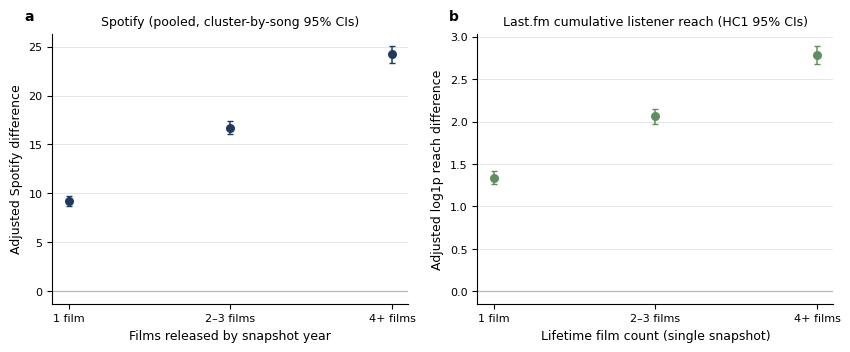

In [5]:
# SI figure: cross-platform repeated-embedding concordance (assembled from
# the notebook 04 pooled time-respecting rows and the notebook 05 Last.fm rows).
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6))
d_sp = repeated[repeated["model"].str.contains("time-respecting")].set_index("term")
order_sp = ["1 realized films vs none", "2-3 realized films vs none", "4+ realized films vs none"]
x = np.arange(3)
errorbarv(axes[0], x, d_sp.loc[order_sp, "estimate"], d_sp.loc[order_sp, "cluster_ci_low"], d_sp.loc[order_sp, "cluster_ci_high"], color=DARK_BLUE)
axes[0].set_xticks(x); axes[0].set_xticklabels(["1 film", "2–3 films", "4+ films"])
axes[0].set_ylabel("Adjusted Spotify difference")
axes[0].set_xlabel("Films released by snapshot year")
axes[0].set_title("Spotify (pooled, cluster-by-song 95% CIs)", fontsize=9)
d_lf = repeated[repeated["model"].str.startswith("Last.fm")].set_index("term")
order_lf = ["1 lifetime films vs none", "2-3 lifetime films vs none", "4+ lifetime films vs none"]
errorbarv(axes[1], x, d_lf.loc[order_lf, "estimate"], d_lf.loc[order_lf, "hc1_ci_low"], d_lf.loc[order_lf, "hc1_ci_high"], color=GREEN)
axes[1].set_xticks(x); axes[1].set_xticklabels(["1 film", "2–3 films", "4+ films"])
axes[1].set_ylabel("Adjusted log1p reach difference")
axes[1].set_xlabel("Lifetime film count (single snapshot)")
axes[1].set_title("Last.fm cumulative listener reach (HC1 95% CIs)", fontsize=9)
for ax_, lab in zip(axes, ["a", "b"]):
    ax_.axhline(0, color=LIGHT_GRAY, lw=0.9)
    ax_.grid(axis="y", color=GRID, lw=0.7)
    panel_label(ax_, lab)
fig.tight_layout()
show_and_save_figure(fig, paths.OUT_FIG_SI / "figure_si_crossplatform_embedding.pdf")